# Analysis: Three Event Case Studies and a System-Level Coda

**Working notes for the report (Section IV). Scaffolding for `06_synthesis` and the slides.**

## What this notebook does

This notebook examines the **epistemic gap** between what was publicly claimed, feared, and denied about three 2025 weather events and what the NWS verification record (IEM COW) holds for those same events. The object of study is the gap itself.

Each case study is a three-way comparison at one event:
1. **The public claim/fear/denial** (documentary record; see `docs/literature.md`).
2. **What the verification record shows** (COW data, scoped to the same event).
3. **The gap between them** (the finding).

Events are scoped to specific offices and days, matching the specificity of the public claims: the gap lives exactly where a claim met a record.

## What the record can be asked (knowable / partly / not)

Applied to every event, and to the system-level coda:

- **Knowable.** For events the record captured: was a warning in effect (`verify`), and with what lead time (`lead0`)? How does that sit against the same office's 2016-2024 baseline for the phenomenon?
- **Partly knowable.** Whether a deviation exceeds normal interannual variation. The system-level coda has the N to support a calibrated inferential statement on this.
- **Beyond this record.** Causation, per-office staffing dose, and the fate of warnings never issued belong to other instruments; this notebook maps where the verification record reaches and where the next instrument would take over.

## Structure

1. Setup and baseline definitions
2. **TO** - May 16-18 2025 KY-MO outbreak (descriptive)
3. **SV** - June 19-22 2025 derecho (descriptive)
4. **FF** - July 4 2025 Kerr County (single-case illustration)
5. **Reach-and-limits coda** - system-wide, placebo-calibrated, outcome-agnostic

## The cross-event shape (what the three studies show together)

Consequence runs opposite to statistical traction. Kerr County (maximum consequence and public alarm) yields the fewest warnings; the June derecho (least public alarm) yields the richest record. The record is most interrogable exactly where the public looked least. That asymmetry is the epistemic finding the three studies establish together.


## 1. Setup and baseline definitions

Loads the cleaned tables and defines the two things every event study reads from: the **event windows** (the office set and day range for each case study) and a **baseline helper** that summarizes how a given office set normally performs for a phenomenon across 2016-2024. Each event study compares its window against that baseline.


In [7]:
import sys
import glob
import json
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.analysis.constants import PHENOMENA_LABELS, PHENOMENA_COLORS
from src.analysis.data import load_events, load_stormreports

# Plot styling: matplotlib-native whitegrid (matches 04_eda)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

CLEAN_DIR = Path("../data/03_cleaning")
RAW_DIR   = Path("../data/01_collection/COW")
IMG_DIR   = Path("../img")
IMG_DIR.mkdir(exist_ok=True)

events       = load_events(CLEAN_DIR)
stormreports = load_stormreports(CLEAN_DIR)

BASELINE_YEARS = range(2016, 2025)   # 2016-2024 inclusive; 2025 is the event year

# Each event is defined by its DOCUMENTED impact counties (state-qualified, as they
# appear in NWS ar_ugcname) drawn from authoritative sources, plus a UTC day range.
# The office set is DERIVED below from which offices warned those counties in the
# collected record, so scope traces to the public record rather than hand-selection.
EVENTS = {
    "TO": {
        "label":    "Tornado - May 16-17 2025 (KY-MO outbreak)",
        "start":    "2025-05-16", "end": "2025-05-19",
        # NWS St. Louis (LSX) and Jackson KY (JKL) damage surveys; AP/Weather.com recap
        "counties": ["Laurel KY", "Pulaski KY", "Russell KY",
                     "St. Louis MO", "St. Louis City MO", "Scott MO"],
    },
    "SV": {
        "label":    "Severe Thunderstorm - June 19-22 2025 (derecho)",
        "start":    "2025-06-19", "end": "2025-06-23",
        # NWS Bismarck (BIS) and Grand Forks (FGF) event summaries; MN DNR Bemidji report
        "counties": ["Barnes ND", "Stutsman ND", "LaMoure ND",
                     "Beltrami MN", "Norman MN"],
    },
    "FF": {
        "label":    "Flash Flood - July 3-4 2025 (Kerr County)",
        "start":    "2025-07-03", "end": "2025-07-05",
        # Commerce OIG-26-017 review; Doggett (2025) inquiry letter
        "counties": ["Kerr TX"],
    },
}


def derive_offices(phen):
    """Derive an event's office set from the warnings that named its documented counties.

    Scans the raw COW JSON for warnings of the given phenomenon issued within the
    event's UTC day range whose ar_ugcname includes one of the documented counties,
    and returns the set of offices that issued them. This ties the office set to the
    public record (NWS county footprints) rather than to manual selection.

    Args:
        phen: Phenomenon code ("TO", "SV", "FF") keying into EVENTS.

    Returns:
        Sorted list of WFO call signs that warned the documented counties in-window.
    """
    e = EVENTS[phen]
    targets = set(e["counties"])
    offices = set()
    for path in glob.glob(str(RAW_DIR / "*_2025.json")):
        with open(path) as f:
            data = json.load(f)
        for feat in data["events"]["features"]:
            p = feat["properties"]
            if p["phenomena"] != phen:
                continue
            if not (e["start"] <= p.get("issue", "")[:10] < e["end"]):
                continue
            if targets & set(p.get("ar_ugcname") or []):
                offices.add(p["wfo"])
    return sorted(offices)


# Derive and cache each event's office set once.
for phen in EVENTS:
    EVENTS[phen]["wfos"] = derive_offices(phen)


def event_warnings(phen):
    """Return the warning rows for an event's phenomenon, window, and derived offices.

    Args:
        phen: Phenomenon code ("TO", "SV", "FF").

    Returns:
        DataFrame of events rows matching the phenomenon, the event's UTC day
        range, and the offices derived from its documented counties.
    """
    e = EVENTS[phen]
    m = (
        (events["phenomena"] == phen)
        & (events["issue"] >= e["start"])
        & (events["issue"] <  e["end"])
        & (events["wfo"].isin(e["wfos"]))
    )
    return events[m]


def baseline_by_year(phen, wfos):
    """Per-year baseline (2016-2024) verify rate and median lead for an office set.

    Args:
        phen: Phenomenon code ("TO", "SV", "FF").
        wfos: List of WFO call signs (the event's derived office set).

    Returns:
        DataFrame indexed by year with columns: n (warning count),
        verify_rate, lead_median (minutes, over verified warnings).
    """
    b = events[
        (events["phenomena"] == phen)
        & (events["wfo"].isin(wfos))
        & (events["year"].isin(BASELINE_YEARS))
    ]
    g = b.groupby("year")
    return pd.DataFrame({
        "n":           g.size(),
        "verify_rate": g["verify"].mean(),
        "lead_median": g["lead0"].median(),
    })


# Confirm each event's documented counties resolve to an office set and window counts.
for phen, e in EVENTS.items():
    w = event_warnings(phen)
    print(f"{e['label']}")
    print(f"   counties: {e['counties']}")
    print(f"   offices (derived): {e['wfos']}")
    print(f"   window: {len(w)} {phen} warnings, verify={w['verify'].mean():.2f}, "
          f"lead0 present={w['lead0'].notna().sum()}/{len(w)}\n")


Tornado - May 16-17 2025 (KY-MO outbreak)
   counties: ['Laurel KY', 'Pulaski KY', 'Russell KY', 'St. Louis MO', 'St. Louis City MO', 'Scott MO']
   offices (derived): ['JKL', 'LMK', 'LSX', 'PAH']
   window: 60 TO warnings, verify=0.37, lead0 present=22/60

Severe Thunderstorm - June 19-22 2025 (derecho)
   counties: ['Barnes ND', 'Stutsman ND', 'LaMoure ND', 'Beltrami MN', 'Norman MN']
   offices (derived): ['BIS', 'FGF']
   window: 89 SV warnings, verify=0.74, lead0 present=66/89

Flash Flood - July 3-4 2025 (Kerr County)
   counties: ['Kerr TX']
   offices (derived): ['EWX']
   window: 13 FF warnings, verify=0.31, lead0 present=4/13



### Reading the verification record: what public data can and cannot assess

A note on the metric, because it bounds every comparison below and is itself a finding.

NWS holds itself to public performance targets. For tornado warnings these are GPRA goals (since 2007): POD >= 72%, lead time >= 13 minutes, FAR <= 71% (OIG-25-026). The natural question is whether each event met the agency's own bar. The public verification record cannot answer it cleanly:

- **POD and lead time are not reconstructable from public data.** The GPRA metrics are segment-based: the tornado track is split into 1-minute segments and each is matched to a warning polygon (Percentage of Event Warned). The openly-queryable IEM COW record carries no tornado track geometry; a tornado storm report is a single point with one timestamp. Our `verify` and `lead0` are warning-to-point-LSR matches (POD2 semantics), a different method. Only a FAR-like quantity (1 - verify rate) is approximable, and even that matches warnings to reports by a different rule than GPRA.
- **The agency's own watchdog flags the same problem.** OIG-25-026, Finding III: "the public-facing GPRA lead-time metric definition is inaccurate, affecting the interpretation and assessment of NWS" tornado warning performance.
- **Substantively, the targets are not consistently met.** Per the same audit, NWS met its FAR goal in 9 of the last 12 years but consistently fell short on POD and lead time; these shortfalls are structural and predate 2025.

Consequence for this notebook: the event comparisons below are **descriptive, against each office's own 2016-2024 record**, not scored against the GPRA goals. The GPRA targets are not overlaid on the figures, because doing so would compare different metrics. That the open record cannot reproduce the agency's own scoreboard is part of the answer to what the public record can be asked.


## 2. TO - May 16-17 2025 Kentucky-Missouri outbreak

**The public claim/fear.** This is the event the press tied most directly to the staffing cuts. The Jackson KY office (JKL) was reported "four meteorologists short ... a 31 percent vacancy rate" and "scrambling to cover the overnight forecast" as the storms moved in (WaPo 2025-05-17; NYT 2025-05-16). The Atlantic framed the outbreak's 42 deaths as a warning about DOGE-driven erosion of forecast lead time (Kayyem 2025). The fear was specific: degraded staffing would degrade detection and lead time during exactly this kind of overnight outbreak.

**What the record shows (vs. 2016-2024 baseline, same offices).** Computed below. The event's verify rate and lead time are read against the natural year-to-year range for JKL, LMK, LSX, PAH.

**What this licenses.** A descriptive comparison of the outbreak's warning record to the same offices' baseline. It does not isolate a staffing effect (no per-office staffing dose; outbreak difficulty and weather vary year to year), and warned-fraction rests on voluntarily filed storm reports.


Tornado - May 16-17 2025 (KY-MO outbreak)
  offices: ['JKL', 'LMK', 'LSX', 'PAH']   event warnings: 60
  verify:  event 0.37   baseline 0.20-0.32 (mean 0.24)
  lead median (min): event 10   baseline 4-9
  TO storm reports: 32   warned fraction 0.94


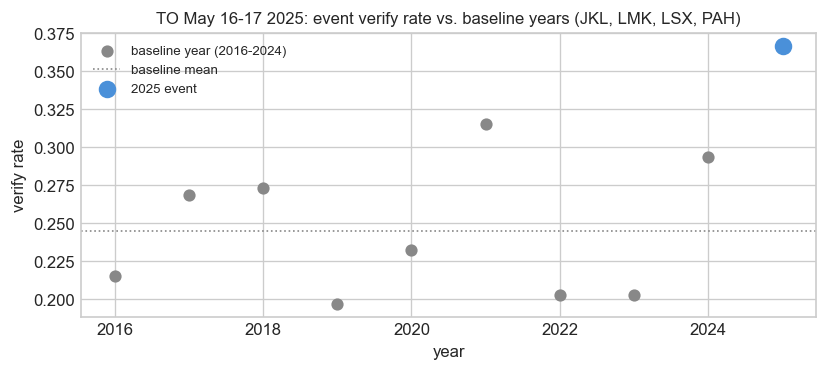

In [8]:
# TO case study: event record vs. same-office 2016-2024 baseline.
phen = "TO"
e    = EVENTS[phen]
ev   = event_warnings(phen)
base = baseline_by_year(phen, e["wfos"])

ev_verify = ev["verify"].mean()
ev_lead   = ev["lead0"].median()
b_vlo, b_vhi, b_vmean = base["verify_rate"].min(), base["verify_rate"].max(), base["verify_rate"].mean()
b_llo, b_lhi = base["lead_median"].min(), base["lead_median"].max()

# TO storm reports in window: warned fraction (coverage from the report side)
srw = stormreports[
    (stormreports["valid"] >= e["start"]) & (stormreports["valid"] < e["end"])
    & (stormreports["wfo"].isin(e["wfos"])) & (stormreports["lsrtype"] == phen)
]

print(f"{e['label']}")
print(f"  offices: {e['wfos']}   event warnings: {len(ev)}")
print(f"  verify:  event {ev_verify:.2f}   baseline {b_vlo:.2f}-{b_vhi:.2f} (mean {b_vmean:.2f})")
print(f"  lead median (min): event {ev_lead:.0f}   baseline {b_llo:.0f}-{b_lhi:.0f}")
print(f"  TO storm reports: {len(srw)}   warned fraction {srw['warned'].mean():.2f}")

# Figure: event verify vs. baseline-year verify points (where the event sits in the band).
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.scatter(base.index, base["verify_rate"], color="#888", s=40, label="baseline year (2016-2024)", zorder=3)
ax.axhline(b_vmean, color="#888", ls=":", lw=1, label="baseline mean")
ax.scatter([2025], [ev_verify], color=PHENOMENA_COLORS["TO"], s=90, zorder=4, label="2025 event")
ax.set_ylabel("verify rate"); ax.set_xlabel("year")
ax.set_title("TO May 16-17 2025: event verify rate vs. baseline years (JKL, LMK, LSX, PAH)", fontsize=10)
ax.legend(fontsize=8, loc="best")
fig.tight_layout()
fig.savefig(IMG_DIR / "05_to_verify_vs_baseline.png", dpi=120, bbox_inches="tight")
plt.show()


## 3. SV - June 19-22 2025 upper-Midwest derecho

**The public claim/fear.** None tied to staffing. The June 19-22 system was covered as weather (the Enderlin ND EF5, the first in 12 years; the 120 mph Bemidji winds; ~60,000 without power), in NWS event summaries (BIS, FGF) and the MN DNR Bemidji report. No source in the 2025 staffing-alarm corpus mentions the derecho, North Dakota, or Minnesota. This was the year's most warning-dense severe event in the collected record, and it drew no public reasoning about staffing in either direction.

**What the record shows (vs. 2016-2024 baseline, same offices).** Computed below for BIS and FGF. Despite being remembered for the EF5, the system was predominantly a severe-thunderstorm warning event in the record.

**What this licenses.** A descriptive comparison only. The richest event for inference at the single-event level, yet the comparison remains descriptive (the system-level coda carries the one calibrated inferential statement). No staffing-dose isolation; warned-fraction rests on voluntary reports.


Severe Thunderstorm - June 19-22 2025 (derecho)
  offices: ['BIS', 'FGF']   event warnings: 89
  verify:  event 0.74   baseline 0.59-0.83 (mean 0.73)
  lead median (min): event 11.5   baseline 10-13
  SV storm reports: 216   warned fraction 0.92


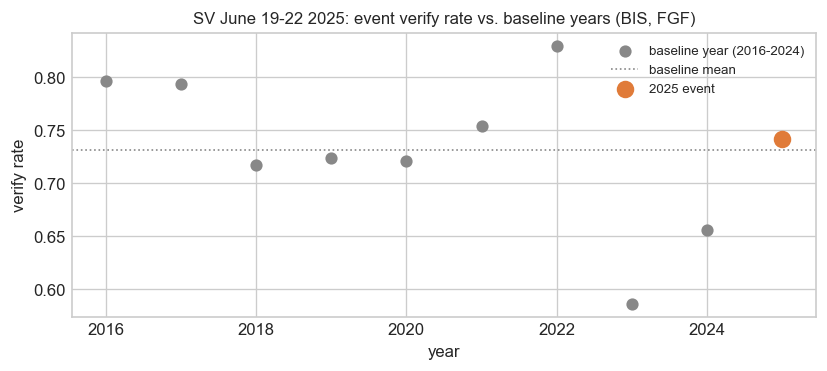

In [9]:
# SV case study: event record vs. same-office 2016-2024 baseline.
phen = "SV"
e    = EVENTS[phen]
ev   = event_warnings(phen)
base = baseline_by_year(phen, e["wfos"])

ev_verify = ev["verify"].mean()
ev_lead   = ev["lead0"].median()
b_vlo, b_vhi, b_vmean = base["verify_rate"].min(), base["verify_rate"].max(), base["verify_rate"].mean()
b_llo, b_lhi = base["lead_median"].min(), base["lead_median"].max()

srw = stormreports[
    (stormreports["valid"] >= e["start"]) & (stormreports["valid"] < e["end"])
    & (stormreports["wfo"].isin(e["wfos"])) & (stormreports["lsrtype"] == phen)
]

print(f"{e['label']}")
print(f"  offices: {e['wfos']}   event warnings: {len(ev)}")
print(f"  verify:  event {ev_verify:.2f}   baseline {b_vlo:.2f}-{b_vhi:.2f} (mean {b_vmean:.2f})")
print(f"  lead median (min): event {ev_lead:.1f}   baseline {b_llo:.0f}-{b_lhi:.0f}")
print(f"  SV storm reports: {len(srw)}   warned fraction {srw['warned'].mean():.2f}")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.scatter(base.index, base["verify_rate"], color="#888", s=40, label="baseline year (2016-2024)", zorder=3)
ax.axhline(b_vmean, color="#888", ls=":", lw=1, label="baseline mean")
ax.scatter([2025], [ev_verify], color=PHENOMENA_COLORS["SV"], s=90, zorder=4, label="2025 event")
ax.set_ylabel("verify rate"); ax.set_xlabel("year")
ax.set_title("SV June 19-22 2025: event verify rate vs. baseline years (BIS, FGF)", fontsize=10)
ax.legend(fontsize=8, loc="best")
fig.tight_layout()
fig.savefig(IMG_DIR / "05_sv_verify_vs_baseline.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. FF - July 4 2025 Kerr County (single-case illustration)

The thinnest event in the window (13 FF warnings at EWX over July 3-4) and the most consequential (139 deaths). Treated as a single case: the record corroborates what was issued, and the weight sits in the documentary record.

**The public claim/denial.** "These offices were fully staffed. The San Angelo office was fully staffed with 12 forecast meteorologists. There were no vacancies. The San Antonio office was operating with 11 forecasters" (Leavitt, White House briefing, 2025-07-07); blaming the administration was "a depraved lie." The Commerce OIG audit found the Austin/San Antonio office (EWX, responsible for Kerr County) "had a total of 27 positions with 6 vacancies," including the Warning Coordination Meteorologist, three of them from "workforce optimization incentives" in May 2025 (OIG-26-017); the Doggett inquiry (2025-07-08) independently cites a 22% EWX vacancy rate. (San Angelo / SJT does not warn Kerr County; EWX does.)

**Issuance held through the cuts.** The figure below shows EWX's flash-flood warning record by year. In 2025, under the documented vacancies, EWX issued more FF warnings than in any prior year in the record, with lead times consistent with its decade-long distribution; the two July 4 Kerr County warnings (201 and 276 minutes of lead) were among the longest-lead FF warnings the office has issued. By the issuance metrics available from public data, the office did its forecasting job.

**The failure was downstream of issuance, in a layer the record cannot measure.** The deaths followed a breakdown in the NWS-to-local handoff, not in warning issuance. WFO staff "were unable to reach the sheriff's office until 4:32 a.m." and the emergency-management coordinator later (OIG-26-017); the Kerrville mayor was unaware until ~5:30 a.m., NWS calls "went to voicemail," and county channels stayed silent until the river was rising (Tx Trib 2025-07-08). The Warning Coordination Meteorologist, "the primary interface between the WFO and core partners" (OIG-26-017), was the vacant position.

**What this licenses, and what it does not.**
- The verification record measures **issuance**: whether a warning was drawn in time and later confirmed. It is structurally silent on **coordination**: whether the warning reached an official who could act. The lethal failure was in the second layer, which COW cannot observe. A citizen analyst working from public data would see adequate issuance and could wrongly infer the system performed.
- Whether the WCM vacancy contributed to the handoff failure is **unresolved**. The OIG does not attribute it; staff said they absorbed the coordination tasks. But every "no impact" statement is the affected WFO staff's own self-report relayed by the OIG ("WFO staff maintained...", "according to WFO personnel..."), not an independent demonstration, and the same staff conceded a prolonged vacancy "might hamper engagement with core partners." A specialist WCM's years of relationships with specific local emergency managers cannot be quickly replaced (cf. Spinrad in WaPo 2025-12-06), which is plausibly load-bearing for exactly the 3 a.m. phone-call failure that occurred. The available data cannot settle the question in either direction.
- Net: the data we can compute measures the wrong layer for the question that mattered, and the one audit touching the right layer rests, on the staffing point, on the affected party's own account. This is reason to doubt the public record is sufficient to support policy conclusions about the staffing-safety link.


Flash Flood - July 3-4 2025 (Kerr County)
  EWX FF warnings July 3-4: 13; verified leads (min): [44, 58, 201, 276]
  EWX 2025 FF volume: 106 (record high); lead median 56 min


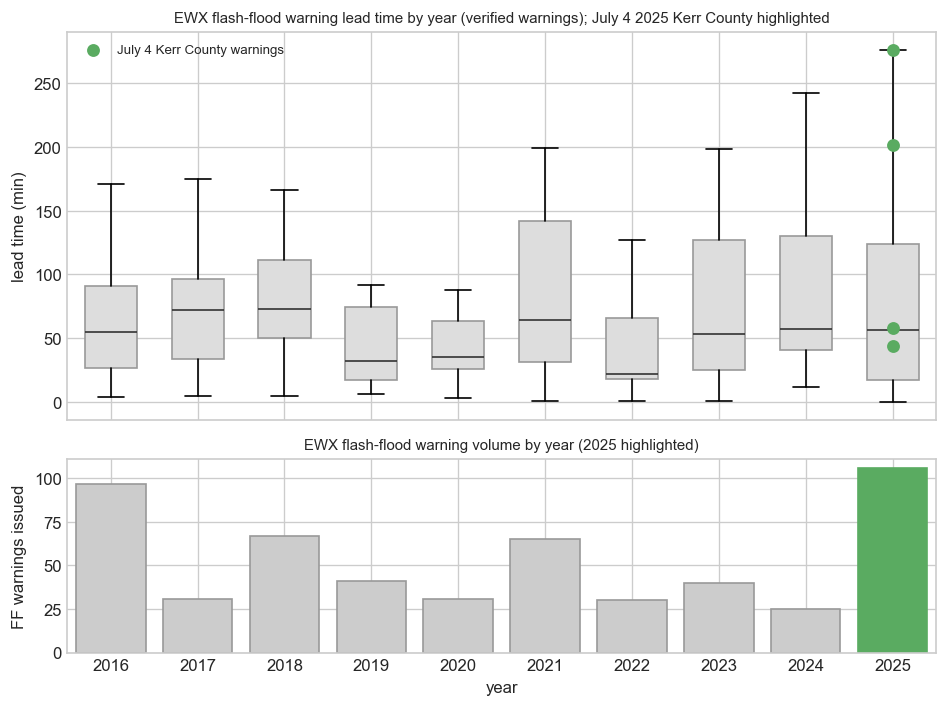

In [10]:
# FF case study: EWX's own flash-flood record by year. Lead time and volume are the
# honest axes for the "issuance held through the cuts" story (verify rate sits mid-low
# in 2025 and is not the point). The lethal failure was in coordination, which these
# issuance metrics cannot show; that is carried in the markdown and the documentary record.
phen = "FF"
e    = EVENTS[phen]
ff   = events[(events["phenomena"] == "FF") & (events["wfo"] == "EWX")].copy()
years = list(range(2016, 2026))

# Event-window warnings and their lead times (the Kerr County warnings).
ev    = event_warnings(phen)
kerr  = ev["lead0"].dropna()
print(f"{e['label']}")
print(f"  EWX FF warnings July 3-4: {len(ev)}; verified leads (min): {sorted(int(x) for x in kerr)}")
print(f"  EWX 2025 FF volume: {(ff['year']==2025).sum()} (record high); "
      f"lead median {ff.loc[ff['year']==2025,'lead0'].median():.0f} min")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, height_ratios=[2, 1])
ffc = PHENOMENA_COLORS["FF"]

data = [ff[ff["year"] == y]["lead0"].dropna().values for y in years]
bp = ax1.boxplot(data, positions=years, widths=0.6, patch_artist=True,
                 showfliers=False, medianprops=dict(color="#333"))
for box in bp["boxes"]:
    box.set(facecolor="#ddd", edgecolor="#999")
ax1.scatter([2025] * len(kerr), kerr, color=ffc, s=45, zorder=5,
            label="July 4 Kerr County warnings")
ax1.set_ylabel("lead time (min)")
ax1.set_title("EWX flash-flood warning lead time by year (verified warnings); "
              "July 4 2025 Kerr County highlighted", fontsize=9)
ax1.legend(fontsize=8, loc="upper left")

vol = [int((ff["year"] == y).sum()) for y in years]
bars = ax2.bar(years, vol, color="#ccc", edgecolor="#999")
bars[-1].set_color(ffc)
ax2.set_ylabel("FF warnings issued"); ax2.set_xlabel("year")
ax2.set_title("EWX flash-flood warning volume by year (2025 highlighted)", fontsize=9)
ax2.set_xticks(years)

fig.tight_layout()
fig.savefig(IMG_DIR / "05_ff_ewx_lead_volume.png", dpi=120, bbox_inches="tight")
plt.show()
